In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

from grb.utils import unit_conversion
from grb.sed import *

## 7DT SED fit

In [3]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy_error"])
print(x0/1e14)

5.903434426266961


In [6]:
eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=x0) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_mJy_error"], x_data_error=df_sdt["frequency_Hz_error"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

16:12 bilby INFO    : Running for label 'grb_fit', output will be saved to 'bilby_out'
16:12 bilby INFO    : Analysis priors:
16:12 bilby INFO    : F_pl=LogUniform(minimum=0.01, maximum=1000.0, name='F_pl', latex_label='F_pl', unit=None, boundary=None)
16:12 bilby INFO    : beta=Uniform(minimum=0, maximum=3, name='beta', latex_label='beta', unit=None, boundary=None)
16:12 bilby INFO    : Av=LogNormal(mu=-1.8881197762551172, sigma=0.9440598881275586, name='Av', latex_label='Av', unit=None, boundary=None)
16:12 bilby INFO    : Analysis likelihood class: <class 'grb.fit._BilbyFitterLikelihood.__new__.<locals>.BilbyLikelihood'>
16:12 bilby INFO    : Analysis likelihood noise evidence: nan
16:12 bilby INFO    : Single likelihood evaluation took nan s
16:12 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 800, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'p

5442it [00:00, ?it/s]

16:12 bilby INFO    : Written checkpoint file bilby_out/grb_fit_resume.pickle
16:13 bilby INFO    : Rejection sampling nested samples to obtain 1384 posterior samples
16:13 bilby INFO    : Sampling time: 0:08:27.836410


16:13 bilby INFO    : Summary of results:
nsamples: 1384
ln_noise_evidence:    nan
ln_evidence: -61.453 +/-  0.184
ln_bayes_factor:    nan +/-  0.184



In [14]:
import ultranest

In [16]:
import bilby
bilby.__file__

'/home/dtak/miniconda3/envs/grb251013c/lib/python3.9/site-packages/bilby/__init__.py'

In [ ]:
ultranest.__file__

'/home/dtak/miniconda3/envs/grb251013c/lib/python3.9/site-packages/ultranest/__init__.py'

In [13]:
alz_sed.sampler.posterior

,F_pl,beta,Av,log_likelihood,log_prior
0,0.314230,0.800476,0.162560,-62.112600,-1.431975
1,0.295794,0.973609,0.116310,-59.962862,-1.072783
2,0.389982,0.893686,0.300996,-58.779758,-2.526279
3,0.357976,0.670146,0.259261,-58.658529,-2.188748
4,0.279687,1.019179,0.065160,-57.940391,-0.796943
...,...,...,...,...,...
1379,0.314788,0.946017,0.138826,-52.150965,-1.277259
1380,0.336083,0.887610,0.192265,-52.148249,-1.696288
1381,0.320356,0.924575,0.153988,-52.144694,-1.394417
1382,0.330927,0.896298,0.179270,-52.144383,-1.594809


In [ ]:
alz_sed.results["weighted_samples"]

{'points': array([[0.31422984, 0.80047632, 0.16255955],
        [0.29579396, 0.97360862, 0.11631006],
        [0.38998156, 0.89368571, 0.30099643],
        ...,
        [0.32035619, 0.92457545, 0.15398751],
        [0.33092747, 0.89629831, 0.17926992],
        [0.33335785, 0.8908494 , 0.18603064]])}

In [8]:
alz_sed.plot_corner()

KeyError: 'weights'

<Axes: xlabel='Frequency', ylabel='Flux'>

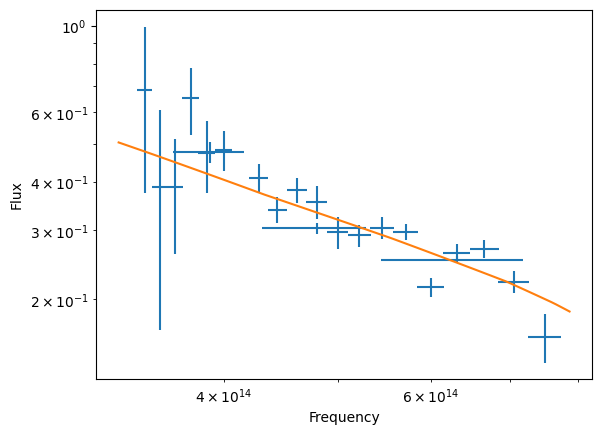

In [15]:
alz_sed.plot_data()
alz_sed.plot_model()

In [9]:
10**-0.83

0.14791083881682077

In [12]:
df_xrt = read_data("xrt")
# df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
# y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
# alz_xrt = Analyzer(df_filtered["Time"]/3600, df_filtered["Flux"], power_law, y_data_error=y_err)
#alz_xrt.run(method="curve_fit")

NameError: name 'alz_xrt' is not defined

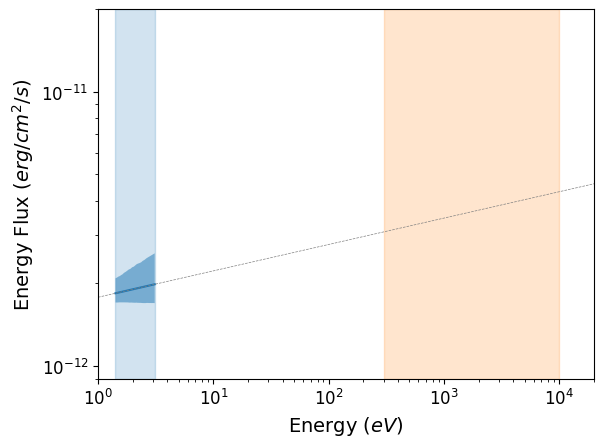

In [13]:
ax = plt.gca()

nu_grid = np.geomspace(min(alz_sed.x_data), max(alz_sed.x_data), 100)

power_law_sed = lambda x, *params: power_law(x, *params[:2], x0=x0)
dataset = alz_sed.get_posterior_predictive_curve(nu_grid, model=power_law_sed, param_indices=[0, 1])

plot_sed(nu_grid, power_law(nu_grid, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", label="7DT (6.5 hrs)")
plot_sed_from_samples(dataset, ax=ax, y_unit="sed", x_unit="eV")

extrapolate_range = np.geomspace(unit_conversion(1, "eV", "Hz"), unit_conversion(200, "keV", "Hz"), 100)
plot_sed(extrapolate_range, power_law(extrapolate_range, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", color="gray", ls="--", lw=0.5)

ax.set_xlim(1, 20000)
ax.set_ylim(9e-13, 2e-11)

ax.axvspan(unit_conversion(min(alz_sed.x_data), "Hz", "eV"), unit_conversion(max(alz_sed.x_data), "Hz", "eV"), color="C0", alpha=0.2)
ax.axvspan(300, 10000, color="C1", alpha=0.2)

ax.plot([300, 10000], [alz_xrt.model(6.5), alz_xrt.model(6.5)], color="C1", ls="--", label="XRT (interpolated at 6.5 hrs)")
ax.legend()
ax.grid()

In [ ]:
from grb.utils import unit_conversion

In [ ]:
10**((np.log10(10000)+np.log10(300))/2)

In [ ]:
data = alz_sed.get_posterior_predictive_curve([unit_conversion(2000, "eV", "Hz")], model=power_law_sed, param_indices=[0, 1])

In [ ]:
data_erg = mJy_to_erg_cm2_s(data[0][1:], unit_conversion(2000, "eV", "Hz"))

In [ ]:
alz_xrt.plot_data(label="XRT")
ax = alz_xrt.plot_model(color="red", lw=0.5, alpha=0.5)
ax.errorbar(6.5, data_erg[1], yerr=[[data_erg[1]-data_erg[0]], [data_erg[2]-data_erg[1]]])
ax.axvline(6.5, color="C1", ls=":", label="XRT (predicted at 6.5 hrs)")
